After SMOTE:
 Fraud
0    110
1    110
Name: count, dtype: int64
Before SMOTE: 0.9166666666666666
After SMOTE: 0.875


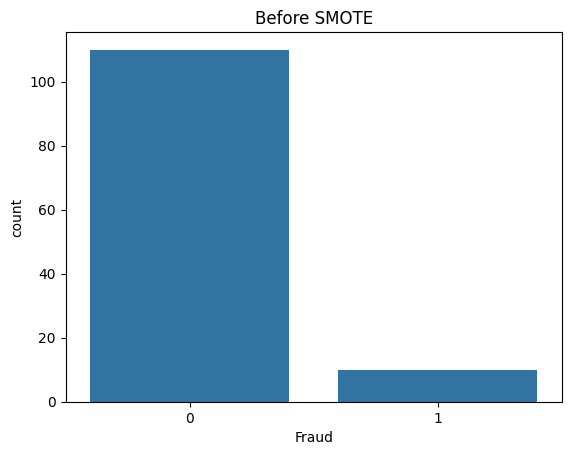

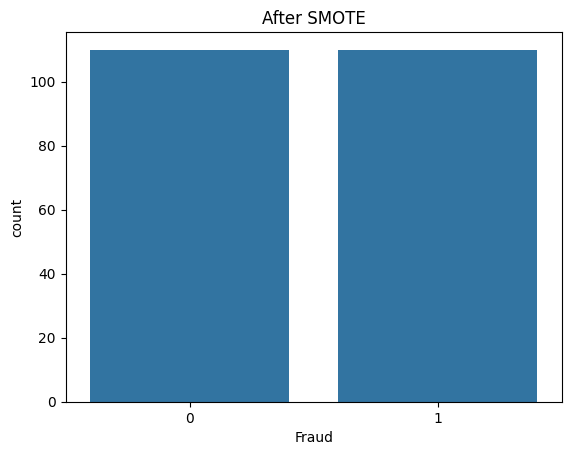

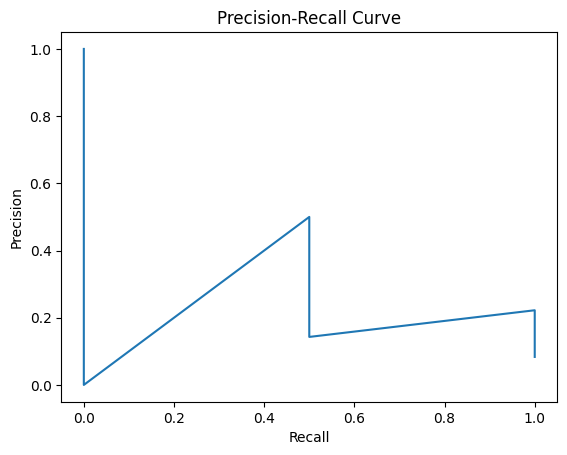

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Downloads\ML\EXP-6\fraud_smote.csv")
df.columns

# Define features and target
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Apply SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE only on training data (IMPORTANT)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Model before SMOTE
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model after SMOTE
model.fit(X_train_res, y_train_res)
y_pred_res = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Before SMOTE:", accuracy_score(y_test, y_pred))
print("After SMOTE:", accuracy_score(y_test, y_pred_res))


import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Before SMOTE")
plt.show()

sns.countplot(x=y_res)
plt.title("After SMOTE")
plt.show()


from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()